In [140]:
import pandas as pd
df=pd.read_csv("../data/processed/sms_scam_detection_dataset_cleaned.csv")
df.head()
df["label"]=df["label"].map(
    {
    "ham":1,
    "spam":0
    }
)
df.head()

,id,label,text,has_url,urls_formatted,url_count,message_length,word_count
0,1,1,Your opinion about me? 1. Over 2. Jada 3. Kusr...,False,NaN,0,136,26
1,2,1,What's up? Do you want me to come online? If y...,False,NaN,0,78,17
2,3,1,So u workin overtime nigpun?,False,NaN,0,28,5
3,4,1,"Also sir, i sent you an email about how to log...",False,NaN,0,173,33
4,5,0,Please Stay At Home. To encourage the notion o...,True,smsg.io,1,146,24


In [152]:
from sklearn.model_selection import train_test_split
X=df["text"]
Y=df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


In [153]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
id                     0
label                  0
text                   0
has_url                0
urls_formatted    121804
url_count              0
message_length         0
word_count             0
dtype: int64


In [34]:
print("Duplicated values:")
print(df.duplicated().sum())

Duplicated values:
0


In [36]:
print("Totalrows:",len(df))
print("Unique messages:",df["text"].nunique())
print("Duplicate messages:", df["text"].duplicated().sum())

Totalrows: 123440
Unique messages: 123440
Duplicate messages: 0


In [29]:
duplicates = df[
    df["cleaned_message"].duplicated(keep=False)
].sort_values("cleaned_message")

print(duplicates)

       label                                    cleaned_message
11001      0  0a network allow company bill sm responsible s...
40002      0  0a network allow company bill sm responsible s...
8304       0  0a network allow company bill sm responsible s...
12127      0  0a network allow company bill sm responsible s...
52722      0  0a network allow company bill sm responsible s...
...      ...                                                ...
37095      1              yupz oredi booked slot 4 weekend liao
86232      1              yupz oredi booked slot 4 weekend liao
91476      1              yupz oredi booked slot 4 weekend liao
85150      1              yupz oredi booked slot 4 weekend liao
38869      1              yupz oredi booked slot 4 weekend liao

[99987 rows x 2 columns]


In [37]:
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True) * 100)
print(df.isnull().sum())

label
1    64197
0    59243
Name: count, dtype: int64
label
1    52.006643
0    47.993357
Name: proportion, dtype: float64
id                     0
label                  0
text                   0
has_url                0
urls_formatted    121804
url_count              0
message_length         0
word_count             0
dtype: int64


In [157]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)

In [158]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [160]:
scoring = {
    "accuracy": "accuracy",
    "spam_precision": make_scorer(
        precision_score,
        pos_label=0,
        zero_division=0
    ),
    "spam_recall": make_scorer(
        recall_score,
        pos_label=0,
        zero_division=0
    ),
    "spam_f1": make_scorer(
        f1_score,
        pos_label=0,
        zero_division=0
    )
}

In [161]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("classifier", MultinomialNB())
])

In [162]:
nb_scores = cross_validate(
    nb_pipeline,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [164]:
print("Naive Bayes")
print("Accuracy:", nb_scores["test_accuracy"].mean())
print("Spam Precision:", nb_scores["test_spam_precision"].mean())
print("Spam Recall:", nb_scores["test_spam_recall"].mean())
print("Spam F1:", nb_scores["test_spam_f1"].mean())

Naive Bayes
Accuracy: 0.7429722987908319
Spam Precision: 0.746914643873828
Spam Recall: 0.702472804411818
Spam F1: 0.7240052096997511


In [165]:
logisticr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [166]:
logisticr_scores = cross_validate(
    lr_pipeline,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [167]:
print("Logistic Regression")
print("Accuracy:", logisticr_scores["test_accuracy"].mean())
print("Spam Precision:", logisticr_scores["test_spam_precision"].mean())
print("Spam Recall:", logisticr_scores["test_spam_recall"].mean())
print("Spam F1:", logisticr_scores["test_spam_f1"].mean())

Logistic Regression
Accuracy: 0.7559137992051677
Spam Precision: 0.765347999441176
Spam Recall: 0.7087393772633772
Spam F1: 0.7359417276568768


In [168]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("classifier", LinearSVC(
        random_state=42
    ))
])

In [169]:
svm_scores = cross_validate(
    svm_pipeline,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [170]:
print("Linear SVM")
print("Accuracy:", svm_scores["test_accuracy"].mean())
print("Spam Precision:", svm_scores["test_spam_precision"].mean())
print("Spam Recall:", svm_scores["test_spam_recall"].mean())
print("Spam F1:", svm_scores["test_spam_f1"].mean())

Linear SVM
Accuracy: 0.7550024134653653
Spam Precision: 0.7637701436917196
Spam Recall: 0.7087393282884895
Spam F1: 0.7352114304466522


In [55]:
from xgboost import XGBClassifier

In [190]:
xgb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

In [191]:
 xgb_50k_scores = cross_validate(
    xgb_pipeline,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [193]:
print("xgb_50k_scores")
print("Accuracy:", xgb_scores["test_accuracy"].mean())
print("Spam Precision:", xgb_scores["test_spam_precision"].mean())
print("Spam Recall:", xgb_scores["test_spam_recall"].mean())
print("Spam F1:", xgb_scores["test_spam_f1"].mean())

xgb_50k_scores
Accuracy: 0.7354382051477605
Spam Precision: 0.7784887203285064
Spam Recall: 0.627231206281982
Spam F1: 0.6947200869651363


In [60]:
logisticr_tfidf_20k = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [63]:
logisticr_20k_scores = cross_validate(
    logisticr_tfidf_20k,
    X,
    Y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [65]:
print("Logistic Regression + 20K TF-IDF")

print("Accuracy:",
      logisticr_20k_scores["test_accuracy"].mean())

print("Spam Precision:",
      logisticr_20k_scores["test_spam_precision"].mean())

print("Spam Recall:",
      logisticr_20k_scores["test_spam_recall"].mean())

print("Spam F1:",
      logisticr_20k_scores["test_spam_f1"].mean())

Logistic Regression + 20K TF-IDF
Accuracy: 0.7876782242384964
Spam Precision: 0.798210161206232
Spam Recall: 0.74626527827173
Spam F1: 0.7713584643265163


In [70]:
logistic_char = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        max_features=30000,
        sublinear_tf=True
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [71]:
logistic_char_scores = cross_validate(
    logistic_char,
    X,
    Y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [73]:
print("Logistic Regression + Character TF-IDF")

print("Accuracy:",
      logistic_char_scores["test_accuracy"].mean())

print("Spam Precision:",
      logistic_char_scores["test_spam_precision"].mean())

print("Spam Recall:",
      logistic_char_scores["test_spam_recall"].mean())

print("Spam F1:",
     logistic_char_scores["test_spam_f1"].mean())

Logistic Regression + Character TF-IDF
Accuracy: 0.7779406999351912
Spam Precision: 0.7825572120138251
Spam Recall: 0.7441047925878468
Spam F1: 0.7628405328615766


In [80]:
logistic_tfidf_30k = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [82]:
logistic_30k_scores = cross_validate(
    logistic_tfidf_30k,
    X,
    Y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression + 30K Word TF-IDF")
print("Accuracy:", logistic_30k_scores["test_accuracy"].mean())
print("Spam Precision:", logistic_30k_scores["test_spam_precision"].mean())
print("Spam Recall:", logistic_30k_scores["test_spam_recall"].mean())
print("Spam F1:", logistic_30k_scores["test_spam_f1"].mean())

Logistic Regression + 30K Word TF-IDF
Accuracy: 0.7928953337653921
Spam Precision: 0.8028814092485831
Spam Recall: 0.7534729281678543
Spam F1: 0.7773847954247574


In [174]:
svm_50k = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", LinearSVC(
        random_state=42
    ))
])

In [175]:
svm_50k_scores = cross_validate(
    svm_50k,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Linear SVM + 50K Word TF-IDF")

print("Accuracy:",
      svm_50k_scores["test_accuracy"].mean())

print("Spam Precision:",
      svm_50k_scores["test_spam_precision"].mean())

print("Spam Recall:",
      svm_50k_scores["test_spam_recall"].mean())

print("Spam F1:",
      svm_50k_scores["test_spam_f1"].mean())

Linear SVM + 50K Word TF-IDF
Accuracy: 0.8042166696895334
Spam Precision: 0.8070762312352839
Spam Recall: 0.7780520153822998
Spam F1: 0.792291383188491


In [176]:
lr_50k = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [177]:
lr_50k_scores = cross_validate(
    lr_50k,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [178]:
print("Logistic Regression + 50K Word TF-IDF")

print("Accuracy:",
      lr_50k_scores["test_accuracy"].mean())

print("Spam Precision:",
      lr_50k_scores["test_spam_precision"].mean())

print("Spam Recall:",
      lr_50k_scores["test_spam_recall"].mean())

print("Spam F1:",
      lr_50k_scores["test_spam_f1"].mean())

Logistic Regression + 50K Word TF-IDF
Accuracy: 0.7909510637820614
Spam Precision: 0.8000389214687559
Spam Recall: 0.7525633934842162
Spam F1: 0.7755445797270889


In [97]:
nb_50k = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", MultinomialNB())
])

In [179]:
nb_50k_scores = cross_validate(
    nb_50k,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
print("Naive Bayes + 50K Word TF-IDF")

print("Accuracy:",
      nb_50k_scores["test_accuracy"].mean())

print("Spam Precision:",
      nb_50k_scores["test_spam_precision"].mean())

print("Spam Recall:",
      nb_50k_scores["test_spam_recall"].mean())

print("Spam F1:",
      nb_50k_scores["test_spam_f1"].mean())

Naive Bayes + 50K Word TF-IDF
Accuracy: 0.7916903335129962
Spam Precision: 0.7831402333282023
Spam Recall: 0.7827150992094317
Spam F1: 0.7829224004713394


In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 98752
Testing samples: 24688


In [108]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

final_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words="english"
    )),
    
    ("classifier", LinearSVC(
        random_state=42
    ))
])

In [110]:
final_svm.fit(X_train, Y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english', sublinear_tf=True)),
                ('classifier', LinearSVC(random_state=42))])

In [114]:
Y_pred = final_svm.predict(X_test)

In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, pos_label=0)
recall = recall_score(Y_test, Y_pred, pos_label=0)
f1 = f1_score(Y_test, Y_pred, pos_label=0)

print("Final Test Results")
print("------------------")
print("Accuracy :", accuracy)
print("Spam Precision :", precision)
print("Spam Recall :", recall)
print("Spam F1 :", f1)

print("\nClassification Report:")
print(classification_report(
    Y_test,
    Y_pred,
    target_names=["Spam", "Legitimate"]
))

Final Test Results
------------------
Accuracy : 0.8079228775113415
Spam Precision : 0.8138302569990286
Spam Recall : 0.7777027597265592
Spam F1 : 0.7953564646987744

Classification Report:
              precision    recall  f1-score   support

        Spam       0.81      0.78      0.80     11849
  Legitimate       0.80      0.84      0.82     12839

    accuracy                           0.81     24688
   macro avg       0.81      0.81      0.81     24688
weighted avg       0.81      0.81      0.81     24688



Confusion Matrix:
[[ 9215  2634]
 [ 2108 10731]]


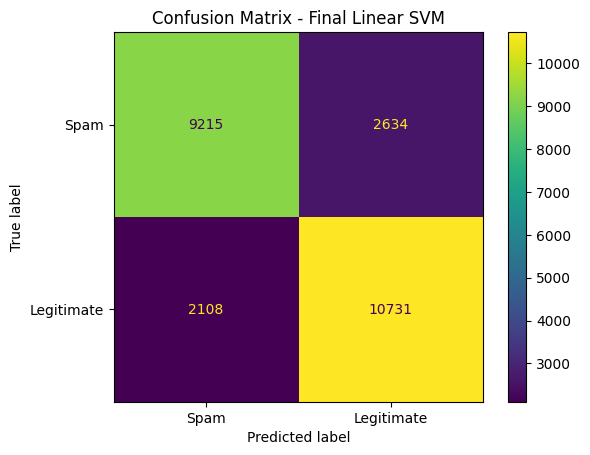

In [117]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Spam", "Legitimate"]
)

disp.plot()
plt.title("Confusion Matrix - Final Linear SVM")
plt.show()

In [119]:
test_results = pd.DataFrame({
    "message": X_test,
    "actual": Y_test,
    "predicted": Y_pred
})

false_negatives = test_results[
    (test_results["actual"] == 0) &
    (test_results["predicted"] == 1)
]

print("False negatives:", len(false_negatives))

false_negatives.head(20)

False negatives: 2634


,message,actual,predicted
55312,RT teatraveler KenLauher Focus On Understandin...,0,1
45200,PotKettleBlack amused irritated by friends com...,0,1
67670,stevendrozd Ok you asked for it Har har John P...,0,1
115882,Kobe s the very best but I love ALL of the res...,0,1
28112,watching my dogs bark at nothing o to be a dog,0,1
40121,Spread the word looking for a passionate band ...,0,1
102372,Macelleria thx We love NYC,0,1
106203,NewsWatch U S stocks next week The return of p...,0,1
79127,Benedict condom http www metafilter com The Be...,0,1
94436,The Graphic Designer Who Revolutionized the Wa...,0,1


In [120]:
false_positives = test_results[
    (test_results["actual"] == 1) &
    (test_results["predicted"] == 0)
]

print("False positives:", len(false_positives))

false_positives.head(20)

False positives: 2108


,message,actual,predicted
5528,WE REGRET TO INFORM U THAT THE NHS HAS MADE A ...,1,0
34512,I will create a group on facebook against the ...,1,0
52969,RT spam We ve seen a few phishing attempts tod...,1,0
26384,Still a very fun music video to watch,1,0
60664,shivers reading my word draft of stories about...,1,0
73370,God I really don t know what to even say about...,1,0
1625,See the forwarding message for proof,1,0
91313,Got my illegal activity setup all pro thanks t...,1,0
46524,Interesting a study shows you need mg of DHA O...,1,0
113304,Checking out Microsoft PDC http bit ly hAdqM,1,0


In [121]:
false_negatives = test_results[
    (test_results["actual"] == 0) &
    (test_results["predicted"] == 1)
]

print(false_negatives[["message", "actual", "predicted"]].head(50))

                                                  message  actual  predicted
55312   RT teatraveler KenLauher Focus On Understandin...       0          1
45200   PotKettleBlack amused irritated by friends com...       0          1
67670   stevendrozd Ok you asked for it Har har John P...       0          1
115882  Kobe s the very best but I love ALL of the res...       0          1
28112      watching my dogs bark at nothing o to be a dog       0          1
40121   Spread the word looking for a passionate band ...       0          1
102372                         Macelleria thx We love NYC       0          1
106203  NewsWatch U S stocks next week The return of p...       0          1
79127   Benedict condom http www metafilter com The Be...       0          1
94436   The Graphic Designer Who Revolutionized the Wa...       0          1
58166                    Smoked chicken http post ly IDdo       0          1
28427   Itsy is a compact and streamlined Twitter clie...       0          1

In [122]:
false_positives = test_results[
    (test_results["actual"] == 1) &
    (test_results["predicted"] == 0)
]

print(false_positives[["message", "actual", "predicted"]].head(50))

                                                  message  actual  predicted
5528    WE REGRET TO INFORM U THAT THE NHS HAS MADE A ...       1          0
34512   I will create a group on facebook against the ...       1          0
52969   RT spam We ve seen a few phishing attempts tod...       1          0
26384               Still a very fun music video to watch       1          0
60664   shivers reading my word draft of stories about...       1          0
73370   God I really don t know what to even say about...       1          0
1625                 See the forwarding message for proof       1          0
91313   Got my illegal activity setup all pro thanks t...       1          0
46524   Interesting a study shows you need mg of DHA O...       1          0
113304       Checking out Microsoft PDC http bit ly hAdqM       1          0
6820    billymax I think they do unless they re Ron Bu...       1          0
97649   RT SilkCharm to the people who found my blog y...       1          0

In [123]:
svm_50k_no_stopwords = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ("classifier", LinearSVC(
        random_state=42
    ))
])

In [125]:
svm_no_stop_scores = cross_validate(
    svm_50k_no_stopwords,
    X_train,
    Y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("Linear SVM + 50K TF-IDF - No Stop Words")

print("Accuracy:",
      svm_no_stop_scores["test_accuracy"].mean())

print("Spam Precision:",
      svm_no_stop_scores["test_spam_precision"].mean())

print("Spam Recall:",
      svm_no_stop_scores["test_spam_recall"].mean())

print("Spam F1:",
      svm_no_stop_scores["test_spam_f1"].mean())

Linear SVM + 50K TF-IDF - No Stop Words
Accuracy: 0.7944345142594927
Spam Precision: 0.7956534028569001
Spam Recall: 0.7692533584696202
Spam F1: 0.7822253378852251


In [183]:
from sklearn.model_selection import GridSearchCV

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", LinearSVC(
        random_state=42
    ))
])

param_grid = {
    "classifier__C": [0.01, 0.1, 0.5, 1, 2, 5, 10]
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=50000,
                                                        ngram_range=(1, 2),
                                                        stop_words='english',
                                                        sublinear_tf=True)),
                                       ('classifier',
                                        LinearSVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 0.5, 1, 2, 5, 10]},
             scoring='f1', verbose=1)

In [184]:
print("Best parameters:")
print(grid_search.best_params_)

print("Best CV F1:")
print(grid_search.best_score_)

Best parameters:
{'classifier__C': 0.5}
Best CV F1:
0.8150312842842917


In [186]:
def print_cv_results(model_name, scores):

    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    print(
        "Fold Accuracies : ",
        np.round(scores["test_accuracy"], 4)
    )

    print(
        "Mean Accuracy   : ",
        round(scores["test_accuracy"].mean(), 4)
    )

    print(
        "Standard Dev.   : ",
        round(scores["test_accuracy"].std(), 4)
    )

    print(
        "Fold Precision  : ",
        np.round(scores["test_spam_precision"], 4)
    )

    print(
        "Mean Precision  : ",
        round(scores["test_spam_precision"].mean(), 4)
    )

    print(
        "Standard Dev.   : ",
        round(scores["test_spam_precision"].std(), 4)
    )

    print(
        "Fold Recall     : ",
        np.round(scores["test_spam_recall"], 4)
    )

    print(
        "Mean Recall     : ",
        round(scores["test_spam_recall"].mean(), 4)
    )

    print(
        "Standard Dev.   : ",
        round(scores["test_spam_recall"].std(), 4)
    )

    print(
        "Fold F1         : ",
        np.round(scores["test_spam_f1"], 4)
    )

    print(
        "Mean F1         : ",
        round(scores["test_spam_f1"].mean(), 4)
    )

    print(
        "Standard Dev.   : ",
        round(scores["test_spam_f1"].std(), 4)
    )

In [188]:
import numpy as np

In [194]:
print_cv_results(
    "Naive Bayes + 50K Word TF-IDF",
    nb_50k_scores
)

print_cv_results(
    "Logistic Regression + 50K Word TF-IDF",
    lr_50k_scores
)

print_cv_results(
    "Linear SVM + 50K Word TF-IDF",
    svm_50k_scores
)
print_cv_results(
    "XGBoost + 50K Word TF-IDF",
    xgb_50k_scores
)


Naive Bayes + 50K Word TF-IDF
Fold Accuracies :  [0.7878 0.7918 0.7918 0.7925 0.7946]
Mean Accuracy   :  0.7917
Standard Dev.   :  0.0022
Fold Precision  :  [0.7786 0.7843 0.7827 0.7817 0.7883]
Mean Precision  :  0.7831
Standard Dev.   :  0.0032
Fold Recall     :  [0.7793 0.781  0.7837 0.7874 0.7821]
Mean Recall     :  0.7827
Standard Dev.   :  0.0028
Fold F1         :  [0.779  0.7826 0.7832 0.7846 0.7852]
Mean F1         :  0.7829
Standard Dev.   :  0.0022

Logistic Regression + 50K Word TF-IDF
Fold Accuracies :  [0.7884 0.7941 0.7902 0.7922 0.7899]
Mean Accuracy   :  0.791
Standard Dev.   :  0.002
Fold Precision  :  [0.7963 0.805  0.7982 0.7959 0.8049]
Mean Precision  :  0.8
Standard Dev.   :  0.0041
Fold Recall     :  [0.7512 0.7535 0.7535 0.7626 0.742 ]
Mean Recall     :  0.7526
Standard Dev.   :  0.0066
Fold F1         :  [0.7731 0.7784 0.7752 0.7789 0.7722]
Mean F1         :  0.7755
Standard Dev.   :  0.0027

Linear SVM + 50K Word TF-IDF
Fold Accuracies :  [0.8003 0.8036 0.8033 

In [195]:
best_svm = grid_search.best_estimator_

Y_pred_tuned = best_svm.predict(X_test)

In [198]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Tuned Linear SVM - Final Test Results")
print("--------------------------------------")

print("Accuracy:",
      accuracy_score(Y_test, Y_pred_tuned))

print("Spam Precision:",
      precision_score(Y_test, Y_pred_tuned, pos_label=0))

print("Spam Recall:",
      recall_score(Y_test, Y_pred_tuned, pos_label=0))

print("Spam F1:",
      f1_score(Y_test, Y_pred_tuned, pos_label=0))

print("\nClassification Report:")
print(classification_report(
    Y_test,
    Y_pred_tuned,
    target_names=["Spam", "Legitimate"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_tuned))

Tuned Linear SVM - Final Test Results
--------------------------------------
Accuracy: 0.8098266364225535
Spam Precision: 0.8185218165627782
Spam Recall: 0.7757616676512786
Spam F1: 0.7965683088522033

Classification Report:
              precision    recall  f1-score   support

        Spam       0.82      0.78      0.80     11849
  Legitimate       0.80      0.84      0.82     12839

    accuracy                           0.81     24688
   macro avg       0.81      0.81      0.81     24688
weighted avg       0.81      0.81      0.81     24688


Confusion Matrix:
[[ 9192  2657]
 [ 2038 10801]]


In [204]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier


models = {

    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            stop_words="english"
        )),
        ("classifier", MultinomialNB())
    ]),

    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            stop_words="english"
        )),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),


    "XGBoost": Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            stop_words="english"
        )),
        ("classifier", XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric="logloss"
        ))
    ])
}

In [205]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

for model_name, model in models.items():

    print("\n" + "=" * 60)
    print(model_name + " - Final Test Results")
    print("=" * 60)

    model.fit(X_train, Y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:",
          accuracy_score(Y_test, y_pred))

    print("Spam Precision:",
          precision_score(
              Y_test,
              y_pred,
              pos_label=0,
              zero_division=0
          ))

    print("Spam Recall:",
          recall_score(
              Y_test,
              y_pred,
              pos_label=0,
              zero_division=0
          ))

    print("Spam F1:",
          f1_score(
              Y_test,
              y_pred,
              pos_label=0,
              zero_division=0
          ))

    print("\nClassification Report:")
    print(
        classification_report(
            Y_test,
            y_pred,
            target_names=["Spam", "Legitimate"],
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, y_pred))


Naive Bayes - Final Test Results
Accuracy: 0.7943940375891121
Spam Precision: 0.7883354618986803
Spam Recall: 0.7814161532618786
Spam F1: 0.7848605577689243

Classification Report:
              precision    recall  f1-score   support

        Spam       0.79      0.78      0.78     11849
  Legitimate       0.80      0.81      0.80     12839

    accuracy                           0.79     24688
   macro avg       0.79      0.79      0.79     24688
weighted avg       0.79      0.79      0.79     24688

Confusion Matrix:
[[ 9259  2590]
 [ 2486 10353]]

Logistic Regression - Final Test Results
Accuracy: 0.7937054439403759
Spam Precision: 0.8056460369163952
Spam Recall: 0.7514558190564604
Spam F1: 0.7776079647176979

Classification Report:
              precision    recall  f1-score   support

        Spam       0.81      0.75      0.78     11849
  Legitimate       0.78      0.83      0.81     12839

    accuracy                           0.79     24688
   macro avg       0.79      0.79 

In [200]:
import joblib

joblib.dump(
    best_svm,
    "../models/message/message_svm_final.joblib"
)

print("Final message model saved successfully.")

Final message model saved successfully.


In [201]:
import os

print(os.path.exists("../models/message/message_svm_final.joblib"))

True


In [202]:
print("Training set:")
print(Y_train.value_counts())

print("\nTesting set:")
print(Y_test.value_counts())

Training set:
label
1    51358
0    47394
Name: count, dtype: int64

Testing set:
label
1    12839
0    11849
Name: count, dtype: int64


In [206]:
messages = [
    "Congratulations! You have won $5000. Click this link to claim your prize.",
    "Hey, are you coming to class tomorrow?",
    "Your account has been selected for a reward. Verify your details immediately.",
    "Can you send me the assignment when you get a chance?",
    "URGENT! Your bank account will be suspended. Click here to verify now."
]

predictions = model.predict(messages)

for message, prediction in zip(messages, predictions):

    result = "SPAM" if prediction == 0 else "LEGITIMATE"

    print("-" * 60)
    print("Message:", message)
    print("Prediction:", result)

------------------------------------------------------------
Message: Congratulations! You have won $5000. Click this link to claim your prize.
Prediction: LEGITIMATE
------------------------------------------------------------
Message: Hey, are you coming to class tomorrow?
Prediction: LEGITIMATE
------------------------------------------------------------
Message: Your account has been selected for a reward. Verify your details immediately.
Prediction: LEGITIMATE
------------------------------------------------------------
Message: Can you send me the assignment when you get a chance?
Prediction: LEGITIMATE
------------------------------------------------------------
Message: URGENT! Your bank account will be suspended. Click here to verify now.
Prediction: SPAM


In [208]:
real_world_messages = [

  "hello my friend ,please lend me some money i will provide you back with 25% interest"
]

predictions = model.predict(real_world_messages)

for message, prediction in zip(real_world_messages, predictions):

    result = "SPAM" if prediction == 0 else "LEGITIMATE"

    print("-" * 70)
    print("Message:", message)
    print("Prediction:", result)

----------------------------------------------------------------------
Message: hello my friend ,please lend me some money i will provide you back with 25% interest
Prediction: LEGITIMATE


In [210]:
import joblib

svm_model = joblib.load(
    "../models/message/message_svm_final.joblib"
)

print(svm_model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english', sublinear_tf=True)),
                ('classifier', LinearSVC(C=0.5, random_state=42))])


In [211]:
message = "hello my friend, please lend me some money i will provide you back with 25% interest"

prediction = svm_model.predict([message])[0]
score = svm_model.decision_function([message])[0]

print(
    "Prediction:",
    "SPAM" if prediction == 0 else "LEGITIMATE"
)

print("Decision score:", score)

Prediction: SPAM
Decision score: -0.23916903180876214


In [212]:
subtle_spam_messages = [

    "Hi, just checking if you received the payment details I sent earlier.",

    "Hello, I wanted to follow up regarding the opportunity we discussed. Let me know if you're interested.",

    "Can you confirm your details so I can complete the transfer for you?",

    "I have some money available and can help you with the amount you requested. Please send your account details.",

    "Hey, I noticed your account needs a quick verification before the service can continue.",

    "Please confirm your email address so I can send you the documents.",

    "Your recent transaction requires confirmation. Please review the details when convenient.",

    "I can help you recover the funds. Just send me the information required to verify your account.",

    "There is a small issue with your recent payment. Please confirm the information we have on file."
]

predictions = svm_model.predict(subtle_spam_messages)

scores = svm_model.decision_function(subtle_spam_messages)

for message, prediction, score in zip(
    subtle_spam_messages,
    predictions,
    scores
):
    result = "SPAM" if prediction == 0 else "LEGITIMATE"

    print("-" * 80)
    print("Message:", message)
    print("Prediction:", result)
    print("Decision Score:", round(score, 4))

--------------------------------------------------------------------------------
Message: Hi, just checking if you received the payment details I sent earlier.
Prediction: LEGITIMATE
Decision Score: 0.2199
--------------------------------------------------------------------------------
Message: Hello, I wanted to follow up regarding the opportunity we discussed. Let me know if you're interested.
Prediction: SPAM
Decision Score: -0.0727
--------------------------------------------------------------------------------
Message: Can you confirm your details so I can complete the transfer for you?
Prediction: LEGITIMATE
Decision Score: 0.6017
--------------------------------------------------------------------------------
Message: I have some money available and can help you with the amount you requested. Please send your account details.
Prediction: SPAM
Decision Score: -0.2319
--------------------------------------------------------------------------------
Message: Hey, I noticed your acco

In [213]:
keywords = [
    "verify",
    "account",
    "payment",
    "transaction",
    "transfer",
    "reward",
    "claim",
    "funds",
    "opportunity"
]

results = []

for keyword in keywords:

    mask = X_train.str.contains(
        keyword,
        case=False,
        na=False
    )

    matched_messages = X_train[mask]
    matched_labels = Y_train[mask]

    spam_count = (matched_labels == 0).sum()
    legitimate_count = (matched_labels == 1).sum()
    total = len(matched_labels)

    results.append({
        "Keyword": keyword,
        "Total": total,
        "Spam": spam_count,
        "Legitimate": legitimate_count,
        "Spam %": round(
            (spam_count / total) * 100, 2
        ) if total > 0 else 0
    })

keyword_analysis = pd.DataFrame(results)

keyword_analysis

,Keyword,Total,Spam,Legitimate,Spam %
0,verify,58,54,4,93.10
1,account,460,338,122,73.48
2,payment,117,96,21,82.05
3,transaction,46,36,10,78.26
4,transfer,40,22,18,55.00
5,reward,96,79,17,82.29
6,claim,304,250,54,82.24
7,funds,38,26,12,68.42
8,opportunity,105,70,35,66.67


In [214]:
for keyword in keywords:

    print("\n" + "=" * 80)
    print(f"KEYWORD: {keyword.upper()}")
    print("=" * 80)

    mask = X_train.str.contains(
        keyword,
        case=False,
        na=False
    )

    sample = pd.DataFrame({
        "message": X_train[mask],
        "label": Y_train[mask]
    }).sample(
        min(10, mask.sum()),
        random_state=42
    )

    for _, row in sample.iterrows():

        label = (
            "SPAM"
            if row["label"] == 0
            else "LEGITIMATE"
        )

        print(f"[{label}] {row['message']}")


KEYWORD: VERIFY
[SPAM] RBC Bank Alert: Your online account is temporarily locked due to suspicious actvity. Please login and verify your information. https://si-rbcroyalbank.com/
[SPAM] Good Day! Your Union Bank account has been flagged for fraudulent transaction. Your account will be disabled in 24 hours. Verify your account here: https://tinyurl.com/UBPVerify Good Day! We would like to notify Union Bank users about the data breach happened yesterday. Affected users will receive this message. To avoid disabling of account in 24 hours, update your details here: https://online.unionbankph.com: verify@kalapradarshini.com
[SPAM] Chase Alert (SM):We noticed unusual activities on your account.Visit chaselocked.com/web to verify the activities. Reply STOP to stop.Msg & data rates may apply.
[SPAM] RBC CANADA Security Alert: Your RBC Client Card 4519**** has been temporarily locked due to unusual activity. To Regain Access Visit http://RBC-CANADA-Verify-Secure-Online.Com
[SPAM] <Subject: Pay

In [215]:
import pandas as pd

# Predict on the untouched test set
test_predictions = best_svm.predict(X_test)

# Create analysis dataframe
error_df = pd.DataFrame({
    "message": X_test.reset_index(drop=True),
    "actual": Y_test.reset_index(drop=True),
    "predicted": test_predictions
})

# False Negatives:
# Actual = Spam (0)
# Predicted = Legitimate (1)

false_negatives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
].copy()

print("Total False Negatives:", len(false_negatives))

Total False Negatives: 2657


In [216]:
for i, (_, row) in enumerate(false_negatives.head(50).iterrows(), 1):

    print("=" * 100)
    print(f"FALSE NEGATIVE #{i}")
    print(f"Actual    : SPAM")
    print(f"Predicted : LEGITIMATE")
    print(f"Message   : {row['message']}")

FALSE NEGATIVE #1
Actual    : SPAM
Predicted : LEGITIMATE
Message   : RT teatraveler KenLauher Focus On Understanding Yourself Instead Of Blaming Others http bit ly mOOtC
FALSE NEGATIVE #2
Actual    : SPAM
Predicted : LEGITIMATE
Message   : PotKettleBlack amused irritated by friends comment about large girls in tiny dresses when they are clearly obese circus mirrors Jason
FALSE NEGATIVE #3
Actual    : SPAM
Predicted : LEGITIMATE
Message   : stevendrozd Ok you asked for it Har har John Parr http www youtube com watch v d thIPddFw
FALSE NEGATIVE #4
Actual    : SPAM
Predicted : LEGITIMATE
Message   : Kobe s the very best but I love ALL of the rest of our squad Lamar I know you ll prove all of the naysayers WRONG o
FALSE NEGATIVE #5
Actual    : SPAM
Predicted : LEGITIMATE
Message   : watching my dogs bark at nothing o to be a dog
FALSE NEGATIVE #6
Actual    : SPAM
Predicted : LEGITIMATE
Message   : Spread the word looking for a passionate band irish gypsy brazilian for next saturday in Dev

In [217]:
for i, (_, row) in enumerate(false_negatives.head(50).iterrows(), 1):

    print("=" * 100)
    print(f"FALSE NEGATIVE #{i}")
    print(f"Actual    : SPAM")
    print(f"Predicted : LEGITIMATE")
    print(f"Message   : {row['message']}")

FALSE NEGATIVE #1
Actual    : SPAM
Predicted : LEGITIMATE
Message   : RT teatraveler KenLauher Focus On Understanding Yourself Instead Of Blaming Others http bit ly mOOtC
FALSE NEGATIVE #2
Actual    : SPAM
Predicted : LEGITIMATE
Message   : PotKettleBlack amused irritated by friends comment about large girls in tiny dresses when they are clearly obese circus mirrors Jason
FALSE NEGATIVE #3
Actual    : SPAM
Predicted : LEGITIMATE
Message   : stevendrozd Ok you asked for it Har har John Parr http www youtube com watch v d thIPddFw
FALSE NEGATIVE #4
Actual    : SPAM
Predicted : LEGITIMATE
Message   : Kobe s the very best but I love ALL of the rest of our squad Lamar I know you ll prove all of the naysayers WRONG o
FALSE NEGATIVE #5
Actual    : SPAM
Predicted : LEGITIMATE
Message   : watching my dogs bark at nothing o to be a dog
FALSE NEGATIVE #6
Actual    : SPAM
Predicted : LEGITIMATE
Message   : Spread the word looking for a passionate band irish gypsy brazilian for next saturday in Dev

In [219]:
false_negatives.to_csv(
    "../data/false_negatives.csv",
    index=False
)

print("False negatives saved successfully.")

False negatives saved successfully.


In [220]:
decision_scores = best_svm.decision_function(X_test)

false_negatives["decision_score"] = decision_scores[
    false_negatives.index
]

false_negatives_sorted = false_negatives.sort_values(
    "decision_score",
    ascending=False
)

In [221]:
borderline_fn = false_negatives[
    false_negatives["decision_score"] < 0.5
].sort_values(
    "decision_score",
    ascending=True
)

print("Borderline False Negatives:", len(borderline_fn))

Borderline False Negatives: 1921


In [222]:
for i, (_, row) in enumerate(borderline_fn.head(50).iterrows(), 1):

    print("=" * 100)
    print(f"#{i}")
    print(f"Decision Score: {row['decision_score']:.4f}")
    print(f"Message: {row['message']}")

#1
Decision Score: 0.0001
Message: When you pasteurize milk the body thinks all these warped distorted proteins are foreign mounts an immune response Sally Fallon wapf
#2
Decision Score: 0.0001
Message: What s Television s Next Business Model http bit ly cMyfDR
#3
Decision Score: 0.0003
Message: The Depressing Reality Of Venture Capital As Told Through Very Sad Charts by nichcarlson http bit ly YCNF via alleyinsider
#4
Decision Score: 0.0003
Message: Billy Crudup to Star in Rapp s METAL CHILDREN at Vineyard Theatre http bit ly dg Pky
#5
Decision Score: 0.0006
Message: back from jordan jetlagged
#6
Decision Score: 0.0008
Message: Is maximising shareholder value flawed Is it still relevant in a growth economy like India but made inclusive http bit ly baLXQ
#7
Decision Score: 0.0011
Message: Settlement Freeze What Settlement Freeze http bit ly aY QUk
#8
Decision Score: 0.0013
Message: Cream cheese is good in moderation Stick with the WHITE cheese s as the yellow is the saturated fat that 